# Git cloning

In [64]:
!nvidia-smi

Fri May  8 11:49:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [65]:
%%capture
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt update
!apt install ./nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt --fix-broken install

In [66]:
%cd /content/
!git clone https://github.com/stasostyk/DSMC.git
%cd /content/DSMC/
!git checkout cuda_opt2_collide_particles
!git pull

/content
fatal: destination path 'DSMC' already exists and is not an empty directory.
/content/DSMC
Already on 'cuda_opt2_collide_particles'
Your branch is up to date with 'origin/cuda_opt2_collide_particles'.
Already up to date.


# Serial version

In [67]:
%cd /content/DSMC/serial/
!mkdir build
%cd build
!cmake .. && make -j4

/content/DSMC/serial
mkdir: cannot create directory ‘build’: File exists
/content/DSMC/serial/build
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /content/DSMC/serial/build
[100%] Built target DSMC_ball
[100%] Built target DSMC_wing


In [68]:
%cd /content/DSMC/serial/build/
!./DSMC_ball

/content/DSMC/serial/build
Running Ball case.
INITIALIZATION. Elapsed time: 59.9968 ms
step=0
  NP=200023
  mean_u=(1.051826e+03, 2.820578e-01, -2.654783e-01)
  T=2.028205e+02
  totalCollisions = 7703
step=200
  NP=213581
  mean_u=(9.646119e+02, -4.520457e+00, 1.186303e+00)
  T=3.534134e+02
  totalCollisions = 1869431
step=400
  NP=213741
  mean_u=(9.637710e+02, -4.285496e+00, 1.734763e-01)
  T=3.535075e+02
  totalCollisions = 3907514
step=600
  NP=212649
  mean_u=(9.626645e+02, -5.605589e+00, -9.370480e-02)
  T=3.549822e+02
  totalCollisions = 5946165
step=800
  NP=213405
  mean_u=(9.636563e+02, -4.885049e+00, -7.311347e-01)
  T=3.554578e+02
  totalCollisions = 7973559
step=1000
  NP=213662
  mean_u=(9.623180e+02, -3.615950e+00, -5.314232e-01)
  T=3.567675e+02
  totalCollisions = 10008625
step=1200
  NP=213754
  mean_u=(9.627464e+02, -4.408719e+00, 2.410164e-01)
  T=3.562392e+02
  totalCollisions = 12052056
step=1400
  NP=213876
  mean_u=(9.630853e+02, -4.429695e+00, -6.274388e-02)
  

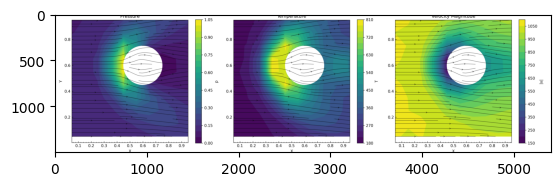

In [69]:
!../../plot.py ball fields_avg.dat ball.png
import matplotlib.pyplot as plt
img = plt.imread("ball.png")
plt.imshow(img)

In [70]:
%cd /content/DSMC/serial/build/
!./DSMC_wing

/content/DSMC/serial/build
Running Wing case.
INITIALIZATION. Elapsed time: 74.7192 ms
step=0
  NP=199876
  mean_u=(9.119223e+02, -5.259024e+02, -7.019506e-01)
  T=2.012235e+02
  totalCollisions = 7568
step=200
  NP=205836
  mean_u=(8.695885e+02, -4.810237e+02, 7.371874e-01)
  T=3.009955e+02
  totalCollisions = 1704919
step=400
  NP=205765
  mean_u=(8.675246e+02, -4.805862e+02, -9.420975e-02)
  T=3.031289e+02
  totalCollisions = 3522020
step=600
  NP=205950
  mean_u=(8.677336e+02, -4.805932e+02, -7.433902e-02)
  T=3.034570e+02
  totalCollisions = 5349022
step=800
  NP=205940
  mean_u=(8.694047e+02, -4.815223e+02, -2.666290e-01)
  T=3.018981e+02
  totalCollisions = 7166911
step=1000
  NP=205896
  mean_u=(8.668754e+02, -4.791374e+02, 5.243479e-01)
  T=3.040992e+02
  totalCollisions = 8989401
step=1200
  NP=205759
  mean_u=(8.665680e+02, -4.801523e+02, 5.565596e-01)
  T=3.031678e+02
  totalCollisions = 10820920
step=1400
  NP=205578
  mean_u=(8.675246e+02, -4.811903e+02, -2.362361e-01)
  

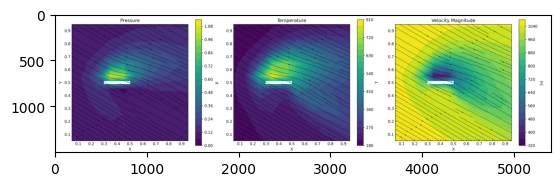

In [71]:
!../../plot.py wing fields_avg.dat wing.png
import matplotlib.pyplot as plt
img = plt.imread("wing.png")
plt.imshow(img)

# CUDA execution


In [72]:
%cd /content/DSMC/cuda/
!rm -rf build/*
!mkdir -p build
%cd build
!cmake ..
!cmake --build .

/content/DSMC/cuda
/content/DSMC/cuda/build
-- The C compiler identification is GNU 11.4.0
-- The CUDA compiler identification is NVIDIA 12.8.93 with host compiler GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CUDA compiler ABI info
-- Detecting CUDA compiler ABI info - done
-- Check for working CUDA compiler: /usr/local/cuda/bin/nvcc - skipped
-- Detecting CUDA compile features
-- Detecting CUDA compile features - done
-- Configuring done (2.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/DSMC/cuda/build
[  5%] Building CUDA object CMakeFiles/DSMC_wing.dir/src/main.cu.o
[ 11%] Building CUDA object CMakeFiles/DSMC_wing.dir/src/math_utils.cu.o
[ 16%] Building CUDA object CMakeFiles/DSMC_wing.dir/src/config.cu.o
[ 22%] Building CUDA object CMakeFiles/DSMC_wing.dir/src/collider.cu.o
[ 27

In [73]:
%cd /content/DSMC/cuda/build/
!./DSMC_ball

/content/DSMC/cuda/build
Running Ball case.
INITIALIZATION. Elapsed time: 237.5364 ms
SIMULATION LOOP. Elapsed time: 280282.5075 ms
step=2000
  NP=26480530
  mean_u=(9.757085e+02, -3.995895e+00, -7.874241e-02)
  T=3.382755e+02
  totalCollisions = 2553971006
ALL PROGRAM FINISHED. Elapsed time: 285408.8409 ms


/content/DSMC/cuda/build


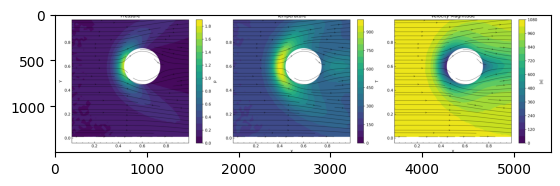

In [74]:
%cd /content/DSMC/cuda/build/
!../../plot.py ball fields_avg.dat ball.png
import matplotlib.pyplot as plt
img = plt.imread("ball.png")
plt.imshow(img)

In [75]:
%cd /content/DSMC/cuda/build/
!./DSMC_wing

/content/DSMC/cuda/build
Running Wing case.
INITIALIZATION. Elapsed time: 214.6639 ms
SIMULATION LOOP. Elapsed time: 271816.2723 ms
step=2000
  NP=25576988
  mean_u=(8.767448e+02, -4.871835e+02, -2.045813e-02)
  T=2.865844e+02
  totalCollisions = 2250038403
ALL PROGRAM FINISHED. Elapsed time: 277529.4662 ms


/content/DSMC/cuda/build


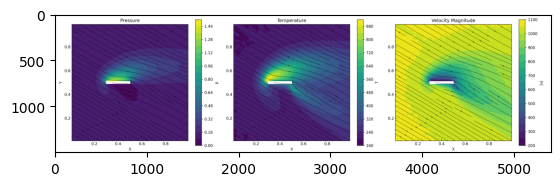

In [76]:
%cd /content/DSMC/cuda/build/
!../../plot.py wing fields_avg.dat wing.png
import matplotlib.pyplot as plt
img = plt.imread("wing.png")
plt.imshow(img)

In [77]:
%cd /content/DSMC/cuda/build/
!nsys profile --stats=true ./DSMC_ball

/content/DSMC/cuda/build
Running Ball case.
INITIALIZATION. Elapsed time: 542.7732 ms
SIMULATION LOOP. Elapsed time: 283294.4429 ms
step=2000
  NP=26478470
  mean_u=(9.757151e+02, -4.059206e+00, -4.618431e-02)
  T=3.383339e+02
  totalCollisions = 2554042441
ALL PROGRAM FINISHED. Elapsed time: 288424.0664 ms
Generating '/tmp/nsys-report-7dd8.qdstrm'
[1/8] [========================100%] report1.nsys-rep
[2/8] [========================100%] report1.sqlite
[3/8] Executing 'nvtx_sum' stats report
SKIPPED: /content/DSMC/cuda/build/report1.sqlite does not contain NV Tools Extension (NVTX) data.
[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls    Avg (ns)      Med (ns)     Min (ns)   Max (ns)    StdDev (ns)           Name         
 --------  ---------------  ---------  ------------  -------------  --------  -----------  -----------  ----------------------
     98.1  288,283,092,846      2,885  99,924,815.5  100,139,310.0   367,047  347,616,776  7,446,038.0  poll  